# Day 27: Understanding Support Vector Machines (SVM)

---
## Overview

Today, we'll delve into Support Vector Machines (SVM), focusing on:
- Understanding the fundamentals of SVM.
- Exploring kernel tricks and margin maximization.
- Applying SVM to real-world datasets.
- Visualizing SVM decision boundaries.

### 1. Understanding Support Vector Machines

SVM is a supervised learning algorithm used for classification and regression tasks. It identifies the optimal hyperplane that best separates data points of different classes by maximizing the margin between them. The data points closest to the hyperplane are termed support vectors, which are critical in defining the decision boundary.

### 2. Kernel Tricks and Margin Maximization

Margin Maximization: SVM aims to find a hyperplane that maximizes the margin—the distance between the hyperplane and the nearest data points from either class. A larger margin often leads to better generalization on unseen data.
Kernel Trick: When data isn't linearly separable in its original space, the kernel trick transforms it into a higher-dimensional space where a linear separator might exist. Common kernels include:
**Linear Kernel**: Suitable for linearly separable data.
**Polynomial Kernel**: Handles data with polynomial relationships.
**Radial Basis Function (RBF) Kernel**: Effective for complex, non-linear data patterns.

### 3. Applying SVM to a Real-World Dataset

We'll use the Iris dataset, a classic dataset in machine learning, to apply SVM. This dataset contains measurements of iris flowers from three species: Setosa, Versicolor, and Virginica. Each sample has four features: sepal length, sepal width, petal length, and petal width.
Steps:
Load the Dataset


In [17]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [15]:
#Load dataset
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Data Preprocessing
Feature Selection: For visualization, we'll select two features: petal length and petal width

In [16]:
X = X [['petal length (cm)', 'petal width (cm)']]

In [7]:
#Split the data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [8]:
#Train the SVM model with linear kerne
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

SVC(kernel='linear')

In [19]:
#Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

Model Accuracy: 80.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45



## 4. Visualizing the Decision Boundary

Visualizing the decision boundary helps in understanding how the SVM model separates different classes.


In [22]:
#Function to plot boundaries
def plot_decision_boundaries(X, y, model):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() -1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:,0], X[:,1], c=y,s=20, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.title('SVM Decision Boundary')
    plt.show()
    

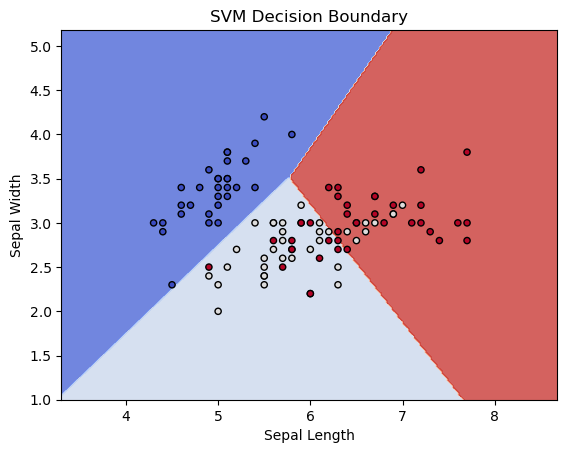

In [23]:
#Plot decision boundaries
plot_decision_boundaries(X_train, y_train, model)